In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression, LinearRegression

In [24]:
Data = pd.read_csv('house_prices_outliers.csv')
Data.head(2)


,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1


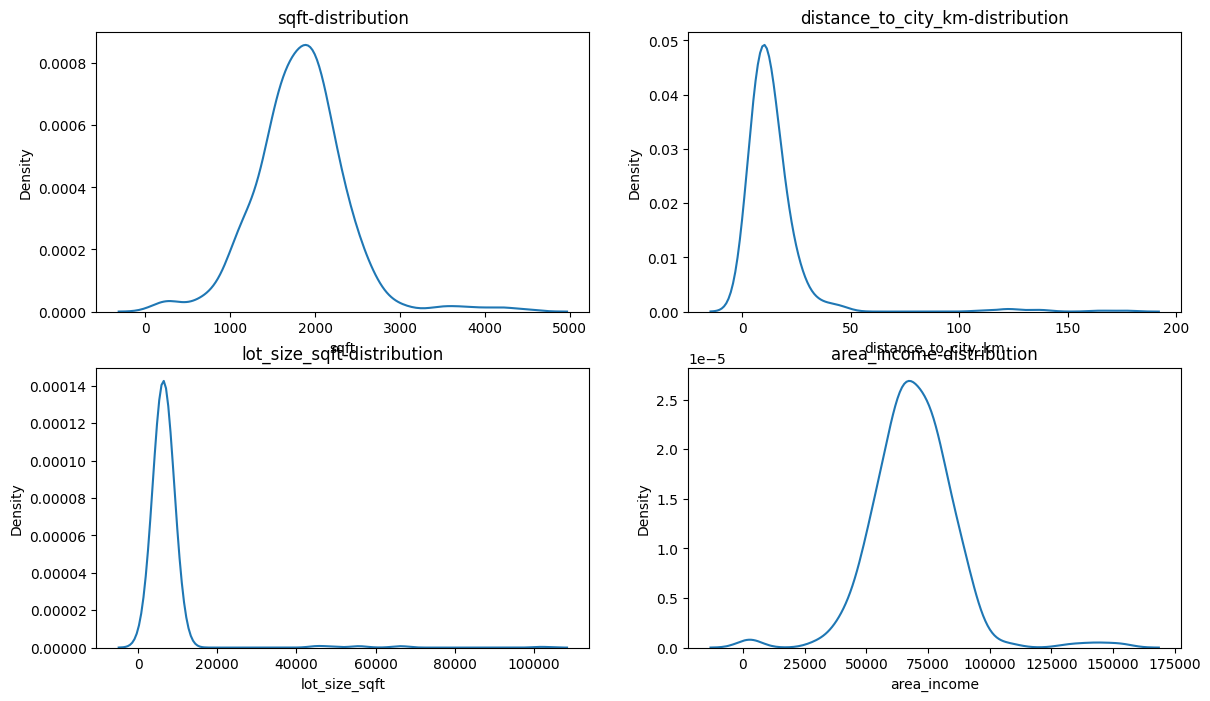

In [25]:

plt.figure(figsize=(14,8))
plt.subplot(221)
sns.kdeplot(Data['sqft'])

plt.title('sqft-distribution')

plt.subplot(222)
sns.kdeplot(Data['distance_to_city_km'])
plt.title('distance_to_city_km-distribution')

plt.subplot(223)
sns.kdeplot(Data['lot_size_sqft'])
plt.title('lot_size_sqft-distribution')

plt.subplot(224)
sns.kdeplot(Data['area_income'])
plt.title('area_income-distribution')

plt.show()

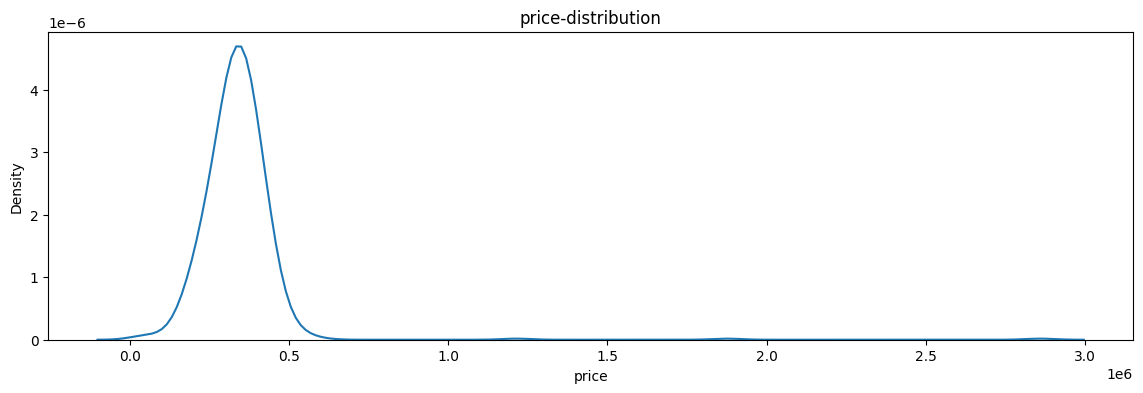

In [26]:
plt.figure(figsize = (14, 4))
sns.kdeplot(Data['price'])

plt.title('price-distribution')

plt.show()

In [28]:
print("mean", Data['sqft'].mean())
print("standard dev", Data['sqft'].std())
print("minimum value", Data['sqft'].min())
print("maximum value", Data['sqft'].max())

mean 1828.584
standard dev 542.7257737337982
minimum value 159.0
maximum value 4497.0


In [29]:
print("Highest value allowed", Data['sqft'].mean() +  3*Data['sqft'].std())
print("lowest value allowed", Data['sqft'].mean() -  3*Data['sqft'].std())

Highest value allowed 3456.761321201395
lowest value allowed 200.40667879860553


In [30]:
## finding the outliers -- using the mean +3std and mean-3std values

Data[(Data['sqft'] > 3456.76) | (Data['sqft'] < 200.40)]

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive
33,159.0,2,37.4,16.4,6868.0,69052.0,331845.0,0
111,3483.0,4,30.5,4.7,8297.0,82227.0,436410.0,1
239,4199.0,3,45.1,8.4,5487.0,45019.0,337574.0,0
251,4226.0,4,31.9,21.8,4575.0,68647.0,347964.0,1
304,3990.0,2,49.4,10.9,9128.0,65087.0,240845.0,0
307,3829.0,2,28.7,17.1,7546.0,91633.0,352632.0,1
308,172.0,1,33.9,14.5,1500.0,90049.0,189934.0,0
348,3720.0,2,45.8,11.4,8956.0,61740.0,350963.0,1
368,3601.0,3,14.2,2.5,48880.0,53989.0,333775.0,0
415,4497.0,2,45.1,5.4,8065.0,80581.0,348604.0,1


## Triming

In [31]:
 
new_df = Data[(Data['sqft'] < 3456.76) | (Data['sqft'] > 200.40)]
new_df

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1
2,2351.0,3,34.1,4.1,8145.0,54458.0,420712.0,1
3,1570.0,2,31.4,15.4,10055.0,78496.0,317073.0,0
4,1666.0,3,7.8,5.2,8033.0,97194.0,356711.0,1
...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,4284.0,58982.0,312448.0,0
496,1237.0,2,15.7,8.9,5709.0,81454.0,261752.0,0
497,2322.0,4,16.4,124.5,4447.0,78585.0,440695.0,1
498,2130.0,5,23.0,6.3,3040.0,60233.0,426268.0,1


## another way  -- by Z-score

In [34]:
Data['sqft_Zscore'] = (Data['sqft'] - Data['sqft'].mean())/ Data['sqft'].std()

Data.sample(5)

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
281,1867.0,3,35.6,14.0,6848.0,62907.0,340624.0,1,0.070783
407,2139.0,4,9.8,21.3,6358.0,80698.0,406016.0,1,0.571957
197,2605.0,4,21.9,7.0,4138.0,87368.0,481998.0,1,1.430586
158,2758.0,4,21.8,16.1,7697.0,79264.0,485622.0,1,1.712497
291,1925.0,2,31.9,7.2,3344.0,73871.0,388451.0,1,0.177651


In [38]:
Data[(Data['sqft_Zscore'] < 3) | (Data['sqft_Zscore'] > -3)]

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0,-0.025029
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1,1.074974
2,2351.0,3,34.1,4.1,8145.0,54458.0,420712.0,1,0.962578
3,1570.0,2,31.4,15.4,10055.0,78496.0,317073.0,0,-0.476454
4,1666.0,3,7.8,5.2,8033.0,97194.0,356711.0,1,-0.299569
...,...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,4284.0,58982.0,312448.0,0,-0.380642
496,1237.0,2,15.7,8.9,5709.0,81454.0,261752.0,0,-1.090024
497,2322.0,4,16.4,124.5,4447.0,78585.0,440695.0,1,0.909144
498,2130.0,5,23.0,6.3,3040.0,60233.0,426268.0,1,0.555374


In [39]:
new_df_zscore = Data[(Data['sqft_Zscore'] < 3) | (Data['sqft_Zscore'] > -3)]
new_df_zscore

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0,-0.025029
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1,1.074974
2,2351.0,3,34.1,4.1,8145.0,54458.0,420712.0,1,0.962578
3,1570.0,2,31.4,15.4,10055.0,78496.0,317073.0,0,-0.476454
4,1666.0,3,7.8,5.2,8033.0,97194.0,356711.0,1,-0.299569
...,...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,4284.0,58982.0,312448.0,0,-0.380642
496,1237.0,2,15.7,8.9,5709.0,81454.0,261752.0,0,-1.090024
497,2322.0,4,16.4,124.5,4447.0,78585.0,440695.0,1,0.909144
498,2130.0,5,23.0,6.3,3040.0,60233.0,426268.0,1,0.555374


## Capping

In [40]:
Upper_limit = Data['sqft'].mean() +  3*Data['sqft'].std()

Lower_limit = Data['sqft'].mean() -  3*Data['sqft'].std()

In [41]:
Upper_limit

np.float64(3456.761321201395)

In [42]:
Lower_limit

np.float64(200.40667879860553)

In [43]:
## going row by row

Data['sqft'] = np.where(
    Data['sqft']>Upper_limit,
    Upper_limit,
    np.where(
        Data['sqft']<Lower_limit,
        Lower_limit,
        Data['sqft']
    )
)

In [45]:
Data['sqft'].describe()

count     500.000000
mean     1820.941808
std       512.984518
min       200.406679
25%      1532.750000
50%      1834.000000
75%      2106.750000
max      3456.761321
Name: sqft, dtype: float64

In [47]:
Data.shape

(500, 9)

##  Now for skewed data

In [82]:
Data['lot_size_sqft'].skew()

np.float64(8.344454073262284)

In [83]:
Data['lot_size_sqft'].describe()

count       500.000000
mean       7277.628000
std        7372.825269
min        1500.000000
25%        5290.750000
50%        6453.000000
75%        7644.750000
max      101921.000000
Name: lot_size_sqft, dtype: float64

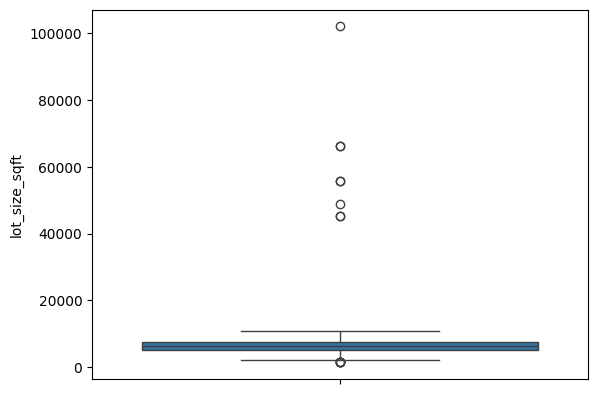

In [84]:
sns.boxplot(Data['lot_size_sqft'])

plt.show()

In [86]:
# finding the IQR

percentile_25  = Data['lot_size_sqft'].quantile(0.25)
percentile_75  = Data['lot_size_sqft'].quantile(0.75)


In [87]:
percentile_75

np.float64(7644.75)

In [88]:
IQR = percentile_75 - percentile_25
IQR

np.float64(2354.0)

In [89]:
upper_limit = percentile_75 + 1.5 * IQR
lower_limit = percentile_25 + 1.5 * IQR

In [90]:
upper_limit

np.float64(11175.75)

In [91]:
lower_limit

np.float64(8821.75)

In [92]:
## Finding the outiers

Data[Data['lot_size_sqft'] > upper_limit]

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
88,1910.000000,3,18.2,15.5,45182.0,67129.0,331783.0,0,0.150013
125,2293.000000,5,33.5,7.2,101921.0,66226.0,438581.0,1,0.855710
163,2044.000000,4,16.5,2.7,66248.0,62714.0,413876.0,1,0.396915
306,1660.000000,3,54.7,12.0,55712.0,77705.0,311597.0,0,-0.310625
361,2057.000000,4,23.6,17.9,66237.0,68061.0,390685.0,1,0.420868
368,3456.761321,3,14.2,2.5,48880.0,53989.0,333775.0,0,3.265767
379,1754.000000,3,16.6,25.8,55728.0,58030.0,295690.0,0,-0.137425
416,1674.000000,3,4.3,4.4,45295.0,92538.0,382219.0,1,-0.284829


In [93]:
Data[Data['lot_size_sqft'] < lower_limit]

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0,-0.025029
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1,1.074974
2,2351.0,3,34.1,4.1,8145.0,54458.0,420712.0,1,0.962578
4,1666.0,3,7.8,5.2,8033.0,97194.0,356711.0,1,-0.299569
5,1563.0,3,70.8,27.0,4596.0,76082.0,204969.0,0,-0.489352
...,...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,4284.0,58982.0,312448.0,0,-0.380642
496,1237.0,2,15.7,8.9,5709.0,81454.0,261752.0,0,-1.090024
497,2322.0,4,16.4,124.5,4447.0,78585.0,440695.0,1,0.909144
498,2130.0,5,23.0,6.3,3040.0,60233.0,426268.0,1,0.555374


## Triming

In [94]:
new_df_trim  = Data[(Data['lot_size_sqft'] > upper_limit) | (Data['lot_size_sqft'] < lower_limit)]
new_df_trim

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
0,1815.0,3,27.4,24.7,8557.0,63317.0,280734.0,0,-0.025029
1,2412.0,3,21.2,8.7,7222.0,62135.0,439430.0,1,1.074974
2,2351.0,3,34.1,4.1,8145.0,54458.0,420712.0,1,0.962578
4,1666.0,3,7.8,5.2,8033.0,97194.0,356711.0,1,-0.299569
5,1563.0,3,70.8,27.0,4596.0,76082.0,204969.0,0,-0.489352
...,...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,4284.0,58982.0,312448.0,0,-0.380642
496,1237.0,2,15.7,8.9,5709.0,81454.0,261752.0,0,-1.090024
497,2322.0,4,16.4,124.5,4447.0,78585.0,440695.0,1,0.909144
498,2130.0,5,23.0,6.3,3040.0,60233.0,426268.0,1,0.555374


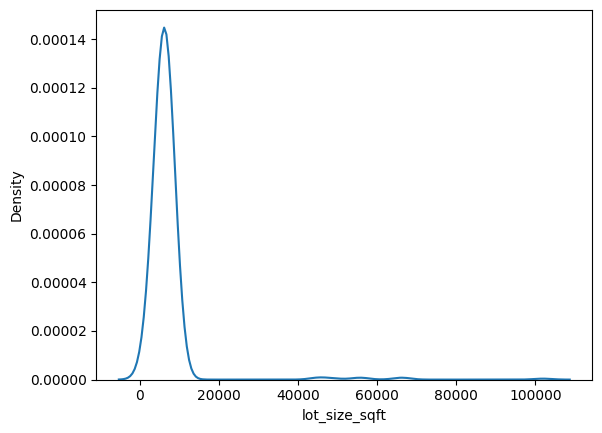

In [97]:
sns.kdeplot(new_df_trim['lot_size_sqft'])
plt.show()

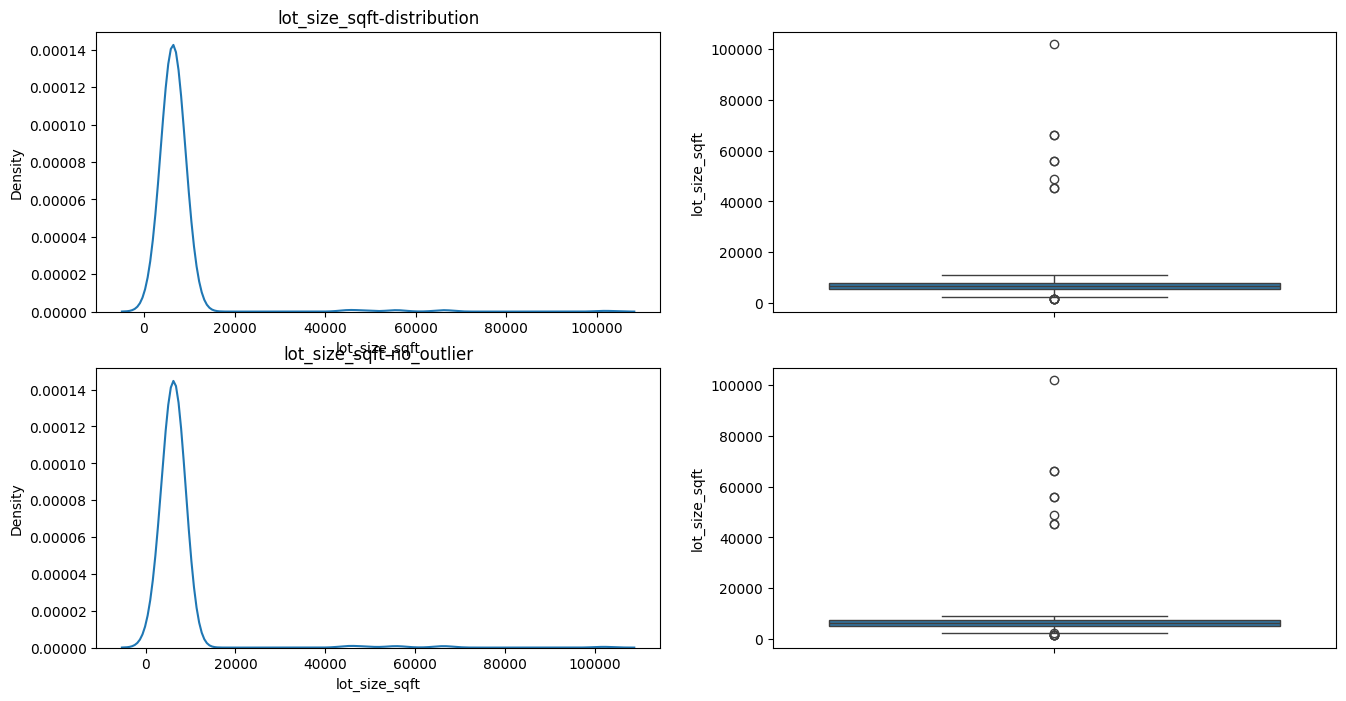

In [96]:
plt.figure(figsize=(16,8))

plt.subplot(221)
sns.kdeplot(Data['lot_size_sqft'])
plt.title('lot_size_sqft-distribution')


plt.subplot(222)
sns.boxplot(Data['lot_size_sqft'])


plt.subplot(223)
sns.kdeplot(new_df_trim['lot_size_sqft'])
plt.title('lot_size_sqft-no_outlier')

plt.subplot(224)
sns.boxplot(new_df_trim['lot_size_sqft'])

plt.show()


## Capping

In [73]:
newdf_cap = Data.copy()

newdf_cap['lot_size_sqft'] = np.where(
    newdf_cap['lot_size_sqft'] >Upper_limit,
    Upper_limit,
    np.where(
        newdf_cap['lot_size_sqft']<Lower_limit,
        Lower_limit,
        Data['lot_size_sqft']
    )
)

In [74]:
newdf_cap

,sqft,bedrooms,age_years,distance_to_city_km,lot_size_sqft,area_income,price,expensive,sqft_Zscore
0,1815.0,3,27.4,24.7,3456.761321,63317.0,280734.0,0,-0.025029
1,2412.0,3,21.2,8.7,3456.761321,62135.0,439430.0,1,1.074974
2,2351.0,3,34.1,4.1,3456.761321,54458.0,420712.0,1,0.962578
3,1570.0,2,31.4,15.4,3456.761321,78496.0,317073.0,0,-0.476454
4,1666.0,3,7.8,5.2,3456.761321,97194.0,356711.0,1,-0.299569
...,...,...,...,...,...,...,...,...,...
495,1622.0,3,24.0,8.7,3456.761321,58982.0,312448.0,0,-0.380642
496,1237.0,2,15.7,8.9,3456.761321,81454.0,261752.0,0,-1.090024
497,2322.0,4,16.4,124.5,3456.761321,78585.0,440695.0,1,0.909144
498,2130.0,5,23.0,6.3,3040.000000,60233.0,426268.0,1,0.555374


In [77]:
newdf_cap['lot_size_sqft'].describe()

count     500.000000
mean     3416.126778
std       232.143924
min      1500.000000
25%      3456.761321
50%      3456.761321
75%      3456.761321
max      3456.761321
Name: lot_size_sqft, dtype: float64

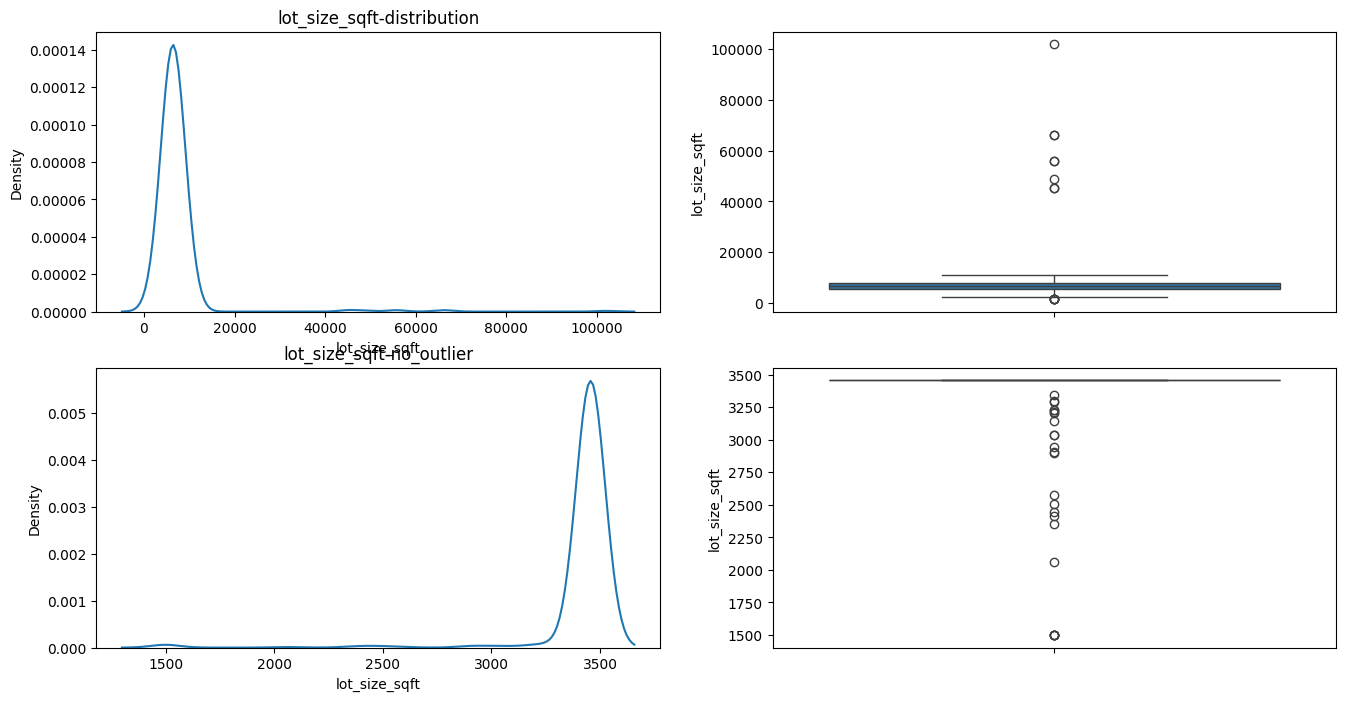

In [75]:
plt.figure(figsize=(16,8))

plt.subplot(221)
sns.kdeplot(Data['lot_size_sqft'])
plt.title('lot_size_sqft-distribution')


plt.subplot(222)
sns.boxplot(Data['lot_size_sqft'])


plt.subplot(223)
sns.kdeplot(newdf_cap['lot_size_sqft'])
plt.title('lot_size_sqft-no_outlier')

plt.subplot(224)
sns.boxplot(newdf_cap['lot_size_sqft'])

plt.show()